In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from typing import Tuple
from tabulate import tabulate

In [2]:
# Section A
def calc_ci(p: float, n: int) -> Tuple[float, float]:
    step = 1.96 * np.sqrt(p * (1 - p) / n)
    return p - step, p + step


print(calc_ci(0.5, 100))

(np.float64(0.402), np.float64(0.598))


Probability of being in the confidence interval: 0.95678


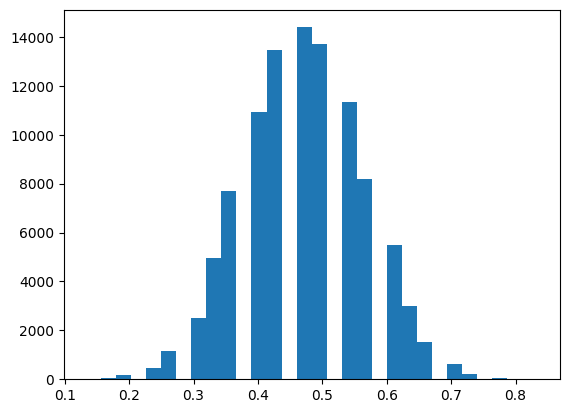

In [3]:
# Section B
def generate_data(n: int, p: float) -> np.array:
    return np.array([1 if np.random.rand() < p else 0 for _ in range(n)])


def monte_carlo_check(n: int, p: float, num_trials: int) -> np.array:
    ps = []
    for _ in range(num_trials):
        data = generate_data(n, p)
        ps.append(np.mean(data))
    return np.array(ps)


def section_b():
    ps = monte_carlo_check(n=30, p=0.47, num_trials=int(1e5))
    plt.hist(ps, bins=30)  # should be normal (CLT)

    cnt = 0
    ci_l, ci_r = calc_ci(0.47, 30)
    for p in ps:
        if ci_l <= p <= ci_r:
            cnt += 1
    print(f"Probability of being in the confidence interval: {cnt / len(ps)}")


section_b()

In [4]:
# Section C
df = pd.read_csv("election.csv")
df = df[
    ["Pollster", "Start Date", "Number of Observations", "Trump", "Clinton", "Mode"]
]
df = df.dropna(subset=["Number of Observations"])
df.head()

,Pollster,Start Date,Number of Observations,Trump,Clinton,Mode
0,Insights West,2016-11-04,940.0,41.0,45.0,Internet
4,IBD/TIPP,2016-11-04,1107.0,43.0,41.0,Live Phone
5,YouGov/Economist,2016-11-04,3669.0,41.0,45.0,Internet
6,YouGov/Economist,2016-11-04,1392.0,6.0,90.0,Internet
7,YouGov/Economist,2016-11-04,1110.0,84.0,4.0,Internet


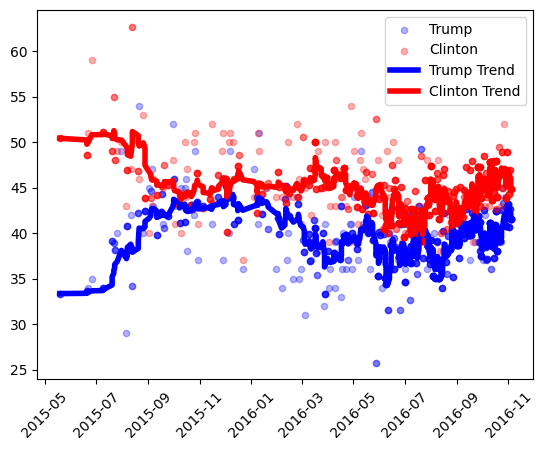

In [5]:
def section_d():
    dates = df["Start Date"].apply(lambda x: datetime.strptime(x, "%Y-%m-%d")).to_list()
    dates.sort()
    trumps = []
    clintons = []
    trump_trends = []
    clinton_trends = []
    beta = 0.9
    for date in dates:
        date_df = df[df["Start Date"] == date.strftime("%Y-%m-%d")
                     ]
        total = date_df["Number of Observations"].sum()
        trump = (date_df["Trump"] * date_df["Number of Observations"]).sum() / total
        clinton = (date_df["Clinton"] * date_df["Number of Observations"]).sum() / total
        trumps.append(trump)
        clintons.append(clinton)
        if trump_trends:
            trump_trends.append(
                trump * (1 - beta) + beta * trump_trends[-1]
            )
            clinton_trends.append(
                clinton * (1 - beta) + beta * clinton_trends[-1]
            )
        else:
            trump_trends.append(trump)
            clinton_trends.append(clinton)

    plt.scatter(dates, trumps, label="Trump", alpha=0.3, s = 20, color='blue')
    plt.scatter(dates, clintons, label="Clinton", alpha=0.3, s = 20, color='red')
    plt.plot(dates, trump_trends, label="Trump Trend", color='blue', lw = 4)
    plt.plot(dates, clinton_trends, label="Clinton Trend", color='red', lw = 4)
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

section_d()

In [6]:
# Section E
total = np.sum(df["Number of Observations"])
print("Total number of voters:", total)

Total number of voters: 1940931.0


In [9]:
# Section F
def get_candidate_aggregate_data(candidate: str):
    count = np.sum(df[candidate] * df["Number of Observations"])
    total = np.sum(df["Number of Observations"])
    return count / 100, count / total


def section_f():
    trump, trump_prop = get_candidate_aggregate_data("Trump")
    clinton, clinton_prop = get_candidate_aggregate_data("Clinton")
    total = np.sum(df["Number of Observations"])

    table = (
        ("", "trump", "clinton", "total"),
        ("Count", trump, clinton, total),
        ("Proportion", f"{trump_prop:.2f}", f"{clinton_prop:.2f}", "1"),
    )
    print(tabulate(table, headers="firstrow", floatfmt=".4f", tablefmt="pretty"))


section_f()

+------------+-----------+-----------+-----------+
|            |   trump   |  clinton  |   total   |
+------------+-----------+-----------+-----------+
|   Count    | 787694.91 | 885299.02 | 1940931.0 |
| Proportion |   40.58   |   45.61   |     1     |
+------------+-----------+-----------+-----------+


In [8]:
def section_g():
    _, trump = get_candidate_aggregate_data("Trump")
    _, clinton = get_candidate_aggregate_data("Clinton")
    print("Trump", calc_ci(trump / 100, total))
    print("Clinton", calc_ci(clinton / 100, total))


section_g()

Trump (np.float64(0.4051427033418969), np.float64(0.40652438837851973))
Clinton (np.float64(0.4554200938173629), np.float64(0.4568215263123584))
